# **Irfan Wasway Trading Strategy Backtesting**

For this project, we will be discussing different trading strategies against the S&P 500, and backtesting them to evaluate their effectiveness.

## 1. Single-Asset Momentum Trading Strategy

### Environment Setup
Let's import the necessary libraries (which we may update as we go) and then fetch adjusted daily close prices for our benchmark index: the S&P 500 ETF, **SPY**.

In [211]:
# Importing all necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

In [150]:
# fetch SPY daily price and volume data
raw_data = yf.download("SPY", start="2018-01-01", end="2026-01-01",auto_adjust=True)

# if yfinance returns a MultiIndex column header, extract SPY's cross-section
if isinstance(raw_data.columns,pd.MultiIndex):
    raw_data=raw_data.xs("SPY",level=1,axis=1)

# construct the DataFrame we will be working with, containing just the adjusted price and volume
df=pd.DataFrame({
    "Price": raw_data["Close"],
    "Volume": raw_data["Volume"]
})
df

[*********************100%***********************]  1 of 1 completed


,Price,Volume
Date,,
2018-01-02,235.954269,86655700
2018-01-03,237.446716,90070400
2018-01-04,238.447510,80636400
2018-01-05,240.036560,83524000
2018-01-08,240.475540,57319200
...,...,...
2025-12-24,686.730530,39445600
2025-12-26,686.660889,41613300
2025-12-29,684.213867,62559500


### Exploratory Data Analysis & Data Cleaning
So far, we have extracted historical trading data for **SPY** and placed adjusted close prices and volume into a Pandas DataFrame. Before constructing signals and running backtests, we must perform essential data cleaning and sanity checks.

1. **Missing Value Check (`NaN` / Nulls):** Ensure there are no missing price points due to exchange holidays or market halts.
2. **Data Integrity & Consistency:** Verify data types and check for non-positive prices or zero-volume anomalies.
3. **Log Return Calculation:** Compute daily log returns ($r_t = \ln(P_t / P_{t-1})$) to establish our baseline return series for benchmark performance analysis.

To prevent gaps in our price time series, we apply a forward-fill method (`ffill`). This carries the last known valid price forward across any isolted missing trading days.

In [153]:
df["Price"]=df["Price"].ffill()
missing_count=df.isnull().sum() # counting the number of rows with missing values
data_types=df.dtypes # checking the data types of prices and volume columns
invalid_prices=(df["Price"]<=0).sum() # counting the number of rows with non-positive prices
zero_volume_days=(df["Volume"]==0).sum() # counting the number of rows with zero volume
print("--- Data Hygiene & Cleaning Report ---")
print(f"Missing Values:\n{missing_count}\n")
print(f"Data Types:\n{data_types}\n")
print(f"Non-positive Prices Count: {invalid_prices}")
print(f"Zero-Volume Trading Days Count: {zero_volume_days}")
print("--------------------------------------")
df

--- Data Hygiene & Cleaning Report ---
Missing Values:
Price     0
Volume    0
dtype: int64

Data Types:
Price     float64
Volume      int64
dtype: object

Non-positive Prices Count: 0
Zero-Volume Trading Days Count: 0
--------------------------------------


,Price,Volume
Date,,
2018-01-02,235.954269,86655700
2018-01-03,237.446716,90070400
2018-01-04,238.447510,80636400
2018-01-05,240.036560,83524000
2018-01-08,240.475540,57319200
...,...,...
2025-12-24,686.730530,39445600
2025-12-26,686.660889,41613300
2025-12-29,684.213867,62559500


### Returns & Volatility Metrics

Now that we have cleaned the price data, we can compute our core statistical metrics: **daily log returns** and **rolling annualised volatility**.

1. **Daily Log Return ($R_t$):** $$R_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$ Log returns are time-additive, meaning the multi-period return is simply the sum of individual daily returns.

2. **Annualised Realised Volatility ($\sigma_{t, N}$):**
   $$\sigma_{t, N} = \text{std}(R_{t-N+1 : t}) \times \sqrt{252}$$
   We compute a 20-day rolling sample standard deviation of daily log returns and scale it by $\sqrt{252}$ to annualise it.

In [155]:
df["Market_Return"]=df["Price"].pct_change() # computing simple daily percentage returns
df["Log_Return"]=np.log(df["Price"]/df["Price"].shift(1)) # computing daily log returns

# computing 20d annualised rolling volatility using daily simple returns
df["Volatility_20D"]=df["Market_Return"].rolling(window=20).std()*np.sqrt(252)
df=df.dropna(subset=["Market_Return"]).copy() # dropping the first row where Market_return is NaN, since day 1 has no previous price
df

,Price,Volume,Market_Return,Log_Return,Volatility_20D
Date,,,,,
2018-01-03,237.446716,90070400,0.006325,0.006305,NaN
2018-01-04,238.447510,80636400,0.004215,0.004206,NaN
2018-01-05,240.036560,83524000,0.006664,0.006642,NaN
2018-01-08,240.475540,57319200,0.001829,0.001827,NaN
2018-01-09,241.019821,57254000,0.002263,0.002261,NaN
...,...,...,...,...,...
2025-12-24,686.730530,39445600,0.003518,0.003512,0.089319
2025-12-26,686.660889,41613300,-0.000101,-0.000101,0.086907
2025-12-29,684.213867,62559500,-0.003564,-0.003570,0.086583


### Simple 20-Day Price Momentum Strategy

We begin by testing a fundamental single-asset momentum rule: **the 20-day Rate-of-Change (ROC)**. We assume that price trends tend to persist over a 1-month trading horizon (~20 trading days):
* **Signal Generation ($S_t$):** Compare today's close price ($P_t$) to the close price 20 trading days ago ($P_{t-20}$):
  $$S_t = \begin{cases} +1 & \text{if } P_t > P_{t-20} \quad \text{(long)} \\ -1 & \text{if } P_t \le P_{t-20} \quad \text{(short)} \end{cases}$$

* **Execution Lag & Position Shifting ($W_t$):**
  To prevent look-ahead bias and simulate execution at the next market open/close, we shift the raw signal by 1 day ($W_t = S_{t-1}$). The position held today is strictly based on the signal generated at the close of yesterday.

In [159]:
lookback=20

# generate a raw signal: +1 if (current price > price 20 days ago), else -1
df["Raw_Signal"]=np.where(df["Price"]>df["Price"].shift(lookback),1,-1)
df.loc[df["Price"].shift(lookback).isna(),"Raw_Signal"]=np.nan # mask the initial lookback window with NaN until enough historical data exists
df["Position"]=df["Raw_Signal"].shift(1) # apply a 1d execution delay to prevent look-ahead bias
df[18:25][["Price","Raw_Signal","Position"]]

,Price,Raw_Signal,Position
Date,,,
2018-01-30,247.358322,NaN,NaN
2018-01-31,247.481232,NaN,NaN
2018-02-01,247.200348,1.0,NaN
2018-02-02,241.818771,1.0,1.0
2018-02-05,231.705200,-1.0,1.0
2018-02-06,236.270401,-1.0,-1.0
2018-02-07,234.988693,-1.0,-1.0


For the first 19 rows, `Raw_Signal` is set to `NaN` because the 20-day lookback window is not yet fully populated. On row 20 the signal produces its first non-null output ($+1$ or $-1$) and `Position` on row $t$ exactly mirros the raw signal on row $t-1$, confirming the execution lag is working and we're not looking ahead.

Now we'll look at our returns. Of course, if we just measure the change in price each day and use our position to determine how much we gain/lose, then we haven't considered real-world features such as execution cost and slippage. Let us assume a penalty of 5 bps (basis-points) from fees, bid-ask spread, and slippage.

### Strategy Performance

To evaluate backtest performance realistically, we must distinguish between **gross** (frictionless) returns and **net** (realized) returns after transaction costs.

- **Gross Strategy Return ($R_{\text{gross}, t}$):**
   $$R_{\text{gross}, t} = W_t \cdot R_{\text{market}, t}$$
   where $W_t$, which is either $+1$ or $-1$, is our shifted position weight held on day $t$.

- **Turnover ($\Delta W_t$):**
   Turnover measures the absolute change in portfolio position from day $t-1$ to day $t$:
   $$\text{Turnover}_t = |W_t - W_{t-1}|$$
   * A hold state ($+1 \to +1$ or $-1 \to -1$) results in $0.0$ turnover.
   * A full position flip ($+1 \to -1$ or $-1 \to +1$) results in $2.0$ turnover (selling out of long, going short).
   * Initial entry from cash ($\text{NaN} \to \pm 1$) results in $1.0$ turnover.

- **Transaction Costs & Net Return ($R_{\text{net}, t}$):**
   Assumes a constant friction penalty of **5 basis points ($0.0005$)** per unit of turnover to model market impact, bid-ask spread, and exchange fees:
   $$\text{Cost}_t = \text{Turnover}_t \times 0.0005$$
   $$R_{\text{net}, t} = R_{\text{gross}, t} - \text{Cost}_t$$

In [163]:
# frictionless returns
df["Strategy_Return_Raw"]=df["Position"]*df["Market_Return"]

cost_bps=0.0005 # we make an assumed constant friction penalty of 5bps
df["Turnover"]=df["Position"].diff().abs() # calculating daily turnover
df.loc[df["Position"].notna() & df["Position"].shift(1).isna(),"Turnover"]=1.0 # accounting for initial strategy entry 
df["Transaction_Cost"]=df["Turnover"]*cost_bps # computing the transaction cost
df["Strategy_Return_Net"]=df["Strategy_Return_Raw"]-df["Transaction_Cost"] # calculating the net returns after the costs
df_clean=df.dropna(subset=["Strategy_Return_Raw"]).copy() # dropping uninitialised rows and creating a clean backtest DataFrame
df_clean.iloc[18:25]

,Price,Volume,Market_Return,Log_Return,Volatility_20D,Raw_Signal,Position,Strategy_Return_Raw,Turnover,Transaction_Cost,Strategy_Return_Net
Date,,,,,,,,,,,
2018-03-01,235.014984,176855100,-0.014541,-0.014647,0.273675,-1.0,-1.0,0.014541,0.0,0.000,0.014541
2018-03-02,236.226425,139083200,0.005155,0.005141,0.274980,-1.0,-1.0,-0.005155,0.0,0.000,-0.005155
2018-03-05,238.956818,97307400,0.011558,0.011492,0.268777,-1.0,-1.0,-0.011558,0.0,0.000,-0.011558
2018-03-06,239.562469,79213200,0.002535,0.002531,0.219909,1.0,-1.0,-0.002535,0.0,0.000,-0.002535
2018-03-07,239.474701,87063500,-0.000366,-0.000366,0.209483,1.0,1.0,-0.000366,2.0,0.001,-0.001366
2018-03-08,240.633545,66901200,0.004839,0.004827,0.208632,1.0,1.0,0.004839,0.0,0.000,0.004839
2018-03-09,244.821060,113625300,0.017402,0.017252,0.158219,1.0,1.0,0.017402,0.0,0.000,0.017402


We can see that on days with turnover (a change in position) the return is affected by the friction considerations we added. Let's try to visualise this.

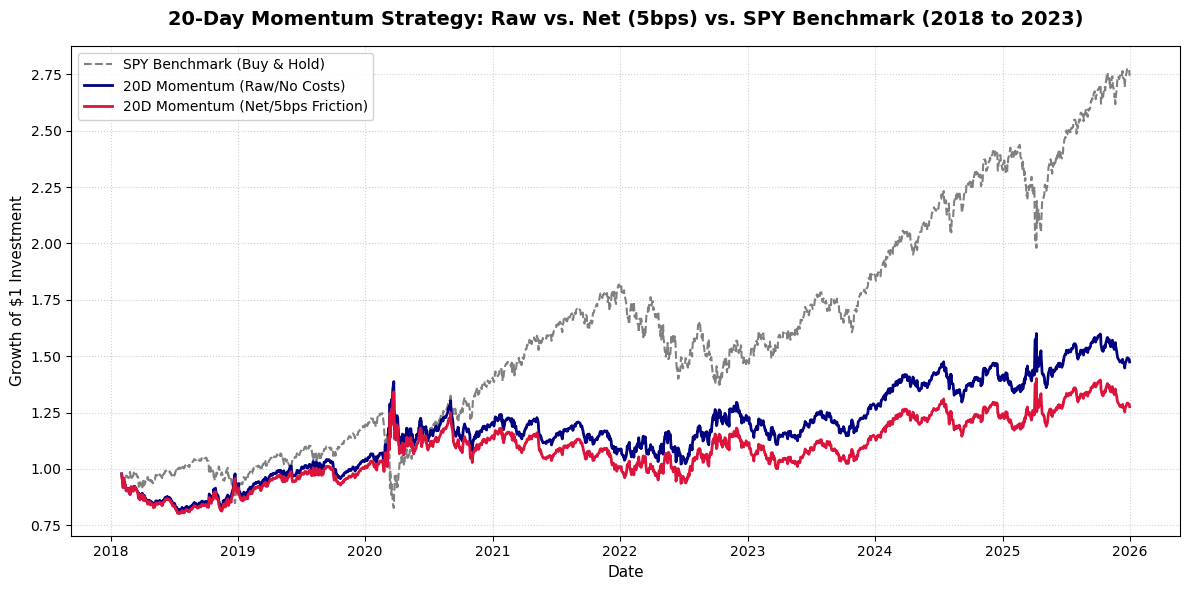

In [165]:
# computing cumulative growth of a £1 investment for our benchmark, raw strategy, and net strategy
df_clean["Cumulative_Benchmark"]=(1+df_clean["Market_Return"]).cumprod()
df_clean["Cumulative_Raw"]=(1+df_clean["Strategy_Return_Raw"]).cumprod()
df_clean["Cumulative_Net"]=(1+df_clean["Strategy_Return_Net"]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(df_clean.index,df_clean["Cumulative_Benchmark"],label="SPY Benchmark (Buy & Hold)", color="gray",linestyle="--",linewidth=1.5)
plt.plot(df_clean.index,df_clean["Cumulative_Raw"],label="20D Momentum (Raw/No Costs)", color="navy",linewidth=2.0)
plt.plot(df_clean.index,df_clean["Cumulative_Net"],label="20D Momentum (Net/5bps Friction)", color="crimson",linewidth=2.0)

plt.title("20-Day Momentum Strategy: Raw vs. Net (5bps) vs. SPY Benchmark (2018 to 2023)",fontsize=14,fontweight="bold",pad=15)
plt.xlabel("Date",fontsize=11)
plt.ylabel("Growth of $1 Investment",fontsize=11)
plt.legend(loc="upper left",frameon=True,facecolor="white",framealpha=0.9)
plt.grid(True,linestyle=":",alpha=0.6)
plt.tight_layout()
plt.show()

Our raw and net momentum strategy both underperform the inex most of the time. The gap between raw and net makes clear how much transaction costs compound over a multi-year backtest when a naive frictionless assumption is used.

Why does this underperform? **SPY** likely mean-reverts over short horizons, so when our strategy sees a 20d price increase it goes long and if the price mean-reverts we lose out. We're also exposed during high-volatility sideways markets.

We can try to improve this by blending signals from multiple lookback horizons instead of just one, and scale position size down during high-volatility periods.

### Strategy Improvements: Multi-Horizon Trend Signals and Volatility Scaling

Now that we have considered ways of improving our strategy, let's try implementing these improvements. Let's have a 10-day, 50-day and 200-day signal so that we can combine small, medium, and large length windows into our signal that will be a real number between +1.0 and -1.0 instead of just binary +1 and -1. We will also adjust our trading volume based on the volatility. Our target annualised volatility will be 15%.

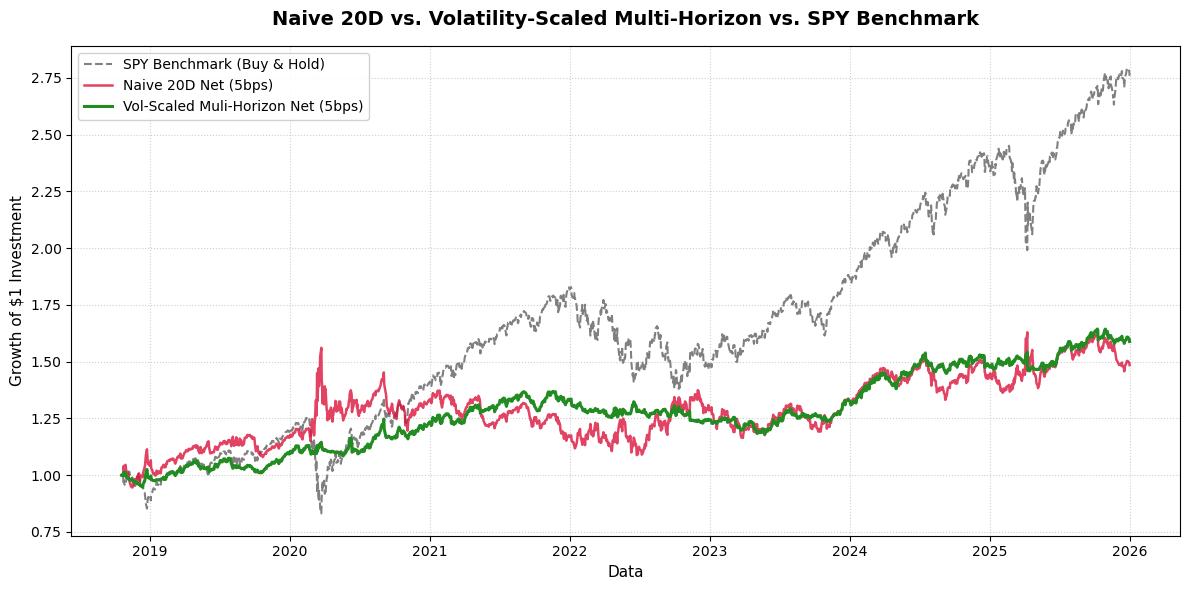

In [170]:
# computing signals for multiple window lengths (10d, 50d and 200d)
df["Signal_10D"]=np.where(df["Price"]>df["Price"].shift(10),1,-1)
df["Signal_50D"]=np.where(df["Price"]>df["Price"].shift(50),1,-1)
df["Signal_200D"]=np.where(df["Price"]>df["Price"].shift(200),1,-1)

# masking uninitialised lookback periods with NaN
df.loc[df["Price"].shift(10).isna(),"Signal_10D"]=np.nan
df.loc[df["Price"].shift(50).isna(),"Signal_50D"]=np.nan
df.loc[df["Price"].shift(200).isna(),"Signal_200D"]=np.nan

# combining our multi-speed lookbacks into one signal between -1.0 and +1.0
df["Blended_Signal"]=(df["Signal_10D"]+df["Signal_50D"]+df["Signal_200D"])/3.0

# dynamic volatility scaling
# we are targeting 15% annualised portfolio volatility
target_vol=0.15
df["Realised_Vol"]=df["Market_Return"].rolling(20).std()*np.sqrt(252)
df["Realised_Vol"]=df["Realised_Vol"].clip(lower=0.05) # if volatility is extremely low, treat it as 5% so that we don't apply extreme leverage during calm periods
df["Vol_Scalar"] = target_vol / df["Realised_Vol"]

# scaling position by our volatility ratio and cap exposure between -100% and +100%
df["Position_Improved_Raw"]=(df["Blended_Signal"]*df["Vol_Scalar"]).clip(lower=-1.0,upper=1.0)
df["Position_Improved"]=df["Position_Improved_Raw"].shift(1) # so that we execute after the signal

# computing returns and transaction costs
df["Improved_Return_Raw"]=df["Position_Improved"]*df["Market_Return"]
df["Turnover_Improved"]=df["Position_Improved"].diff().abs()
df.loc[df["Position_Improved"].notna() & df["Position_Improved"].shift(1).isna(),"Turnover_Improved"]=df["Position_Improved"].abs()
df["Transaction_Cost_Improved"]=df["Turnover_Improved"]*cost_bps
df["Improved_Return_Net"]=df["Improved_Return_Raw"]-df["Transaction_Cost_Improved"]

# creating a clean backtest DataFrame
df_clean_improved=df.dropna(subset=["Improved_Return_Net","Strategy_Return_Net"]).copy()
df_clean_improved["Cumulative_Benchmark"]=(1+df_clean_improved["Market_Return"]).cumprod()
df_clean_improved["Cumulative_Naive_Net"]=(1+df_clean_improved["Strategy_Return_Net"]).cumprod()
df_clean_improved["Cumulative_Improved_Net"]=(1+df_clean_improved["Improved_Return_Net"]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(df_clean_improved.index,df_clean_improved["Cumulative_Benchmark"],label="SPY Benchmark (Buy & Hold)",color="gray",linestyle="--",linewidth=1.5)
plt.plot(df_clean_improved.index,df_clean_improved["Cumulative_Naive_Net"],label="Naive 20D Net (5bps)",color="crimson",linewidth=1.8,alpha=0.8)
plt.plot(df_clean_improved.index,df_clean_improved["Cumulative_Improved_Net"],label="Vol-Scaled Muli-Horizon Net (5bps)",color="forestgreen",linewidth=2.2)
plt.title("Naive 20D vs. Volatility-Scaled Multi-Horizon vs. SPY Benchmark",fontsize=14,fontweight="bold",pad=15)
plt.xlabel("Data",fontsize=11)
plt.ylabel("Growth of $1 Investment",fontsize=11)
plt.legend(loc="upper left",frameon=True,facecolor="white",framealpha=0.9)
plt.grid(True,linestyle=":",alpha=0.6)
plt.tight_layout()
plt.show()

Now looking at this, our total returns across this period seem to be almost the same. So how was this an improvement? Well our first strategy has a lot of variance but our second strategy is much more reliable and stable. This is a very important feature of a good strategy, and will allow for more reliable returns over the long run.

- Avoiding massive drawdowns is important for long-term compounding.
- A strategy with smooth returns can be scaled up using modest leverage to achieve much higher absolute returns at a target risk level.
- Highly volatile strategies with large drawdowns are susceptible to psychological stress when live trading.

To quantify this difference, we'll evaluate some statistics:
1. **Annualised Return ($\mu_A$):**
   $$\mu_A = \left( \prod_{t=1}^T (1 + R_t) \right)^{\frac{252}{T}} - 1$$

2. **Annualised Volatility ($\sigma_A$):**
   $$\sigma_A = \text{std}(R_t) \times \sqrt{252}$$

3. **Sharpe Ratio ($SR$, assuming $R_f = 0$):**
   $$SR = \frac{\mu_A}{\sigma_A}$$

4. **Maximum Drawdown ($MDD$):**
   The peak-to-trough decline measured over the backtest duration:
   $$MDD = \frac{\text{Peak value} - \text{Trough value}}{\text{Peak value}}$$

In [172]:
def calculate_performance_metrics(returns_series,benchmark_returns=None):
    N=len(returns_series)

    # computing Compound Annual Growth Rate (CAGR)
    total_cum_return=(1+returns_series).prod()
    cagr=(total_cum_return**(252/N))-1

    # computing Annualised Volatility
    ann_vol=returns_series.std()*np.sqrt(252)

    # computing Sharpe Ratio, assuming a zero risk-free rate
    sharpe=(returns_series.mean()/returns_series.std())*np.sqrt(252)

    # computing Maximum Drawdown (MDD)
    cum_equity=(1+returns_series).cumprod()
    running_peak=cum_equity.cummax()
    drawdown=(cum_equity-running_peak)/running_peak
    max_drawdown=drawdown.min()

    return{
        "CAGR":f"{cagr:.2%}",
        "Annual Volatility":f"{ann_vol:.2%}",
        "Sharpe Ratio":f"{sharpe:.2f}",
        "Max Drawdown":f"{max_drawdown:.2%}"
    }

metrics_summary=pd.DataFrame({
    "SPY Benchmark (Buy & Hold)":calculate_performance_metrics(df_clean_improved["Market_Return"]),
    "Naive 20D Net Strategy":calculate_performance_metrics(df_clean_improved["Strategy_Return_Net"]),
    "Volatility-Scaled Multi-Horizon Net": calculate_performance_metrics(df_clean_improved["Improved_Return_Net"])
})

metrics_summary

,SPY Benchmark (Buy & Hold),Naive 20D Net Strategy,Volatility-Scaled Multi-Horizon Net
CAGR,15.19%,5.66%,6.66%
Annual Volatility,19.92%,19.93%,9.73%
Sharpe Ratio,0.81,0.38,0.71
Max Drawdown,-33.72%,-30.26%,-13.76%


We can notice an issue with our annual volatility for our new trading strategy. We were aiming for a 15% annual volatility, and whilst we did reduce our volatility, we undershot it and attained 9% volatility even though we were willing to have more risk than this.

After analysing how the position sizing works in the code, I realised two main factors caused this:
- `Blended_Signal` takes the mean of three seperate binary signals (10d, 50d, 200d) and only hits $\pm 1.0$ when all three horizons agree. During transition periods where they disagree, the blended signal drops to $\pm 0.33$.
- We apply `.clip(lower=-1.0,upper=1.0)` to the final position size. When market volatility drops below 15%, `Vol_Scalar` scaled up above $1.0$ to maintain our target exposure, but capping the position with this part of the code prevents us from taking leverage during low-volatility regimes. Because we scale down during high-volatility periods but cannot scale up during calm periods, the realised volatility is suppressed.

To properly target 15%, we can divide the target volatility scalar by the historical average absolute signal strength (~$0.67$). Also, we can extend the leverage bounds from $[-1.0,1.0]$ to $[-2.0,2.0]$, allowing up to 200% position exposure and allows the volatility scalar enough room to maintain target risk during calm periods.

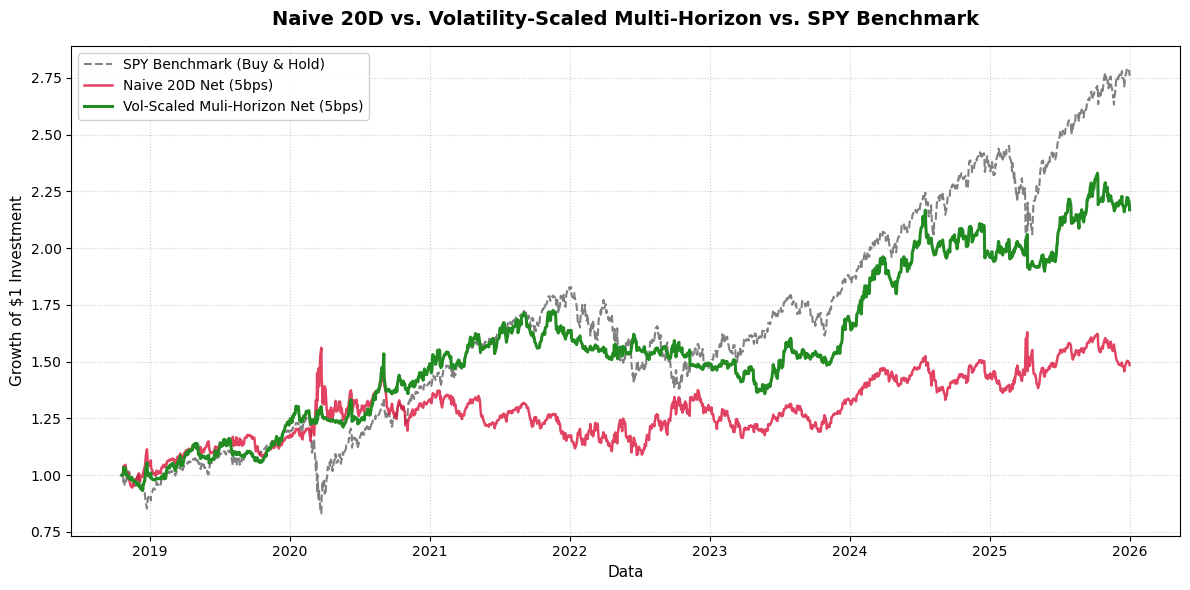

In [174]:
# computing signals for multiple window lengths (10d, 50d and 200d)
df["Signal_10D"]=np.where(df["Price"]>df["Price"].shift(10),1,-1)
df["Signal_50D"]=np.where(df["Price"]>df["Price"].shift(50),1,-1)
df["Signal_200D"]=np.where(df["Price"]>df["Price"].shift(200),1,-1)

# masking uninitialised lookback periods with NaN
df.loc[df["Price"].shift(10).isna(),"Signal_10D"]=np.nan
df.loc[df["Price"].shift(50).isna(),"Signal_50D"]=np.nan
df.loc[df["Price"].shift(200).isna(),"Signal_200D"]=np.nan

# combining our multi-speed lookbacks into one signal between -1.0 and +1.0
df["Blended_Signal"]=(df["Signal_10D"]+df["Signal_50D"]+df["Signal_200D"])/3.0

# dynamic volatility scaling
# we are targeting 15% annualised portfolio volatility
target_vol=0.15

# computing annualised market volatility over 2d rolling window
df["Market_Vol_20d"]=df["Market_Return"].rolling(20).std()*np.sqrt(252)
df["Market_Vol_20d"]=df["Market_Vol_20d"].clip(lower=0.05) # floor realised volatility at 5% to avoid dividing by zero or applying extreme leverage during calm periods

# computing the historical mean absolute strength of the blended signal
avg_signal_strength=df["Blended_Signal"].abs().replace(0,np.nan).expanding().mean() # replacing 0 with NaN to ensure neutral days don't skew the mean downward#
# checking if the signal column is empty or uninitialised then default to 0.67
avg_signal_strength=avg_signal_strength.fillna(0.67).replace(0,0.67)

# computing the position scaling factor
vol_scalar=(target_vol/df["Market_Vol_20d"])/avg_signal_strength
df["Position_Improved_Raw"] = (df["Blended_Signal"] * vol_scalar).clip(lower=-2.0, upper=2.0) # expanding limits to [-2.0,2.0] to allow for moderate leverage
df["Position_Improved"] = df["Position_Improved_Raw"].shift(1)  # shifting positions by a day to execute trades after the signal is observed

# computing returns and transaction costs
df["Improved_Return_Raw"]=df["Position_Improved"]*df["Market_Return"]

df["Turnover_Improved"]=df["Position_Improved"].diff().abs()
first_traded_idx=df["Position_Improved"].first_valid_index()
if first_traded_idx is not None:
    df.loc[first_traded_idx,"Turnover_Improved"]=abs(df.loc[first_traded_idx,"Position_Improved"])
df["Transaction_Cost_Improved"]=df["Turnover_Improved"]*cost_bps
df["Improved_Return_Net"]=df["Improved_Return_Raw"]-df["Transaction_Cost_Improved"]

# creating a clean backtest DataFrame
df_clean_improved=df.dropna(subset=["Improved_Return_Net","Strategy_Return_Net"]).copy()
df_clean_improved["Cumulative_Benchmark"]=(1+df_clean_improved["Market_Return"]).cumprod()
df_clean_improved["Cumulative_Naive_Net"]=(1+df_clean_improved["Strategy_Return_Net"]).cumprod()
df_clean_improved["Cumulative_Improved_Net"]=(1+df_clean_improved["Improved_Return_Net"]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(df_clean_improved.index,df_clean_improved["Cumulative_Benchmark"],label="SPY Benchmark (Buy & Hold)",color="gray",linestyle="--",linewidth=1.5)
plt.plot(df_clean_improved.index,df_clean_improved["Cumulative_Naive_Net"],label="Naive 20D Net (5bps)",color="crimson",linewidth=1.8,alpha=0.8)
plt.plot(df_clean_improved.index,df_clean_improved["Cumulative_Improved_Net"],label="Vol-Scaled Muli-Horizon Net (5bps)",color="forestgreen",linewidth=2.2)
plt.title("Naive 20D vs. Volatility-Scaled Multi-Horizon vs. SPY Benchmark",fontsize=14,fontweight="bold",pad=15)
plt.xlabel("Data",fontsize=11)
plt.ylabel("Growth of $1 Investment",fontsize=11)
plt.legend(loc="upper left",frameon=True,facecolor="white",framealpha=0.9)
plt.grid(True,linestyle=":",alpha=0.6)
plt.tight_layout()
plt.show()

In [176]:
metrics_summary=pd.DataFrame({
    "SPY Benchmark (Buy & Hold)":calculate_performance_metrics(df_clean_improved["Market_Return"]),
    "Naive 20D Net Strategy":calculate_performance_metrics(df_clean_improved["Strategy_Return_Net"]),
    "Volatility-Scaled Multi-Horizon Net": calculate_performance_metrics(df_clean_improved["Improved_Return_Net"])
})

metrics_summary

,SPY Benchmark (Buy & Hold),Naive 20D Net Strategy,Volatility-Scaled Multi-Horizon Net
CAGR,15.19%,5.66%,11.39%
Annual Volatility,19.92%,19.93%,15.58%
Sharpe Ratio,0.81,0.38,0.77
Max Drawdown,-33.72%,-30.26%,-21.23%


Now we can clearly see that our annual volatility is much closer to our target volatility.

- The annualised volatility was decreased compared to the naive strategy, creating a much smoother equity curve
- The strategy's Sharpe ratio nearly doubled, bringing its risk-adjusted efficiency close to the **SPY** benchmark
- Scaling exposure inversely to the 20d realised volatility decreased the maximum drawdown significantly, protecting the portfolio equity during market shocks

## 2. Econometric Modelling and Statistical Arbitrage

Before we can build statistical arbitrage or pair-trading strategies, we must understand stationarity.

A time series $X_t$ is strictly **stationary** if its statistical properties (mean, variance, autocovariance) do not change over time. So the mean and variance is constant for all time, and the covariance only depends on the lag and not the time we measure it.

Raw asset prices like **SPY** or **QQQ** are almost always non-stationary. They are classified as $I(1)$ (integrated of order 1) meaning that taking their first difference yields a stationary series $I(0)$.

### The Augmented Dickey-Fuller (ADF) Test

To prove whether a time series is stationary or contains a **unit root** we use the Augmented Dickey-Fuller (ADF) test based on the regression modeL:
$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta Y_{t-i} + \varepsilon_t,$$
where
- $\Delta y_t = y_t - y_{t-1}$ is the first difference of the time series at time $t$
- $\alpha$ is a constant drift term
- $\beta t$ is a deterministic time trend term
- $\gamma$ is the parameter of interest (where $\gamma = \rho - 1$ and $\rho$ is the coefficient on $y_{t-1}$
- $p$ is the lag length chosen to eliminate serial correlation in the residual $\varepsilon_t$

The test evaluates the parameter $\gamma$.
- Null hypothesis ($H_0$): $\gamma = 0\;(\rho=0)$. The time series has a unit root (non-stationary)
- Alternative hypothesis ($H_1$): $\gamma<0\;(\rho<0)$. The time series does not have a unit root (stationary)

If the resulting $p \text{-value}<0.05$ we reject $H_0$ at the $5\%$ significance level and conclude that the series is stationary.

How we will proceed:
- fetch historical close price data for two highly correlated liquid ETFs: **SPY** and **QQQ** from 2018 to present
- compute their daily log returns
- run the ADF test on **SPY** raw price levels, **QQQ** raw price levels, **SPY** daily log returns, **QQQ** daily log returns

[*********************100%***********************]  2 of 2 completed


Data Hygiene and Cleanning Report
Missing Price Values:
Ticker
QQQ    0
SPY    0
dtype: int64

Missing Volume Values:
Ticker
QQQ    0
SPY    0
dtype: int64

Price Data Types:
Ticker
QQQ    float64
SPY    float64
dtype: object

Non-positive Prices Count:
Ticker
QQQ    0
SPY    0
dtype: int64

Zero-Volume Trading Days Count:
Ticker
QQQ    0
SPY    0
dtype: int64


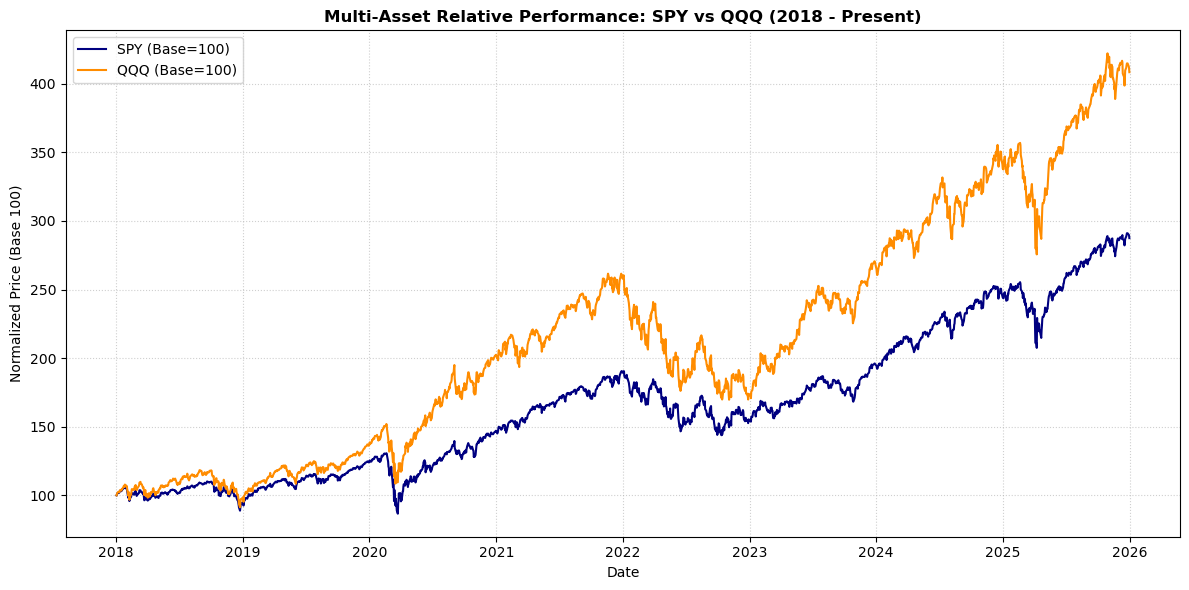

In [179]:
# fetch SPY and QQQ daily price and volume data
tickers=["SPY","QQQ"]
raw_data = yf.download(tickers, start="2018-01-01", end="2026-01-01",auto_adjust=True)

# extracting price and volume matrices
prices=raw_data["Close"].copy()
volume=raw_data["Volume"].copy()

# checking our data
prices=prices.ffill()
volume=volume.ffill()
df["Price"]=df["Price"].ffill()
missing_prices=prices.isnull().sum()
missing_volume=volume.isnull().sum()
price_dtypes=prices.dtypes
invalid_prices=(prices<=0).sum()
zero_volume_days=(volume==0).sum()
print("Data Hygiene and Cleanning Report")
print(f"Missing Price Values:\n{missing_prices}\n")
print(f"Missing Volume Values:\n{missing_volume}\n")
print(f"Price Data Types:\n{price_dtypes}\n")
print(f"Non-positive Prices Count:\n{invalid_prices}\n")
print(f"Zero-Volume Trading Days Count:\n{zero_volume_days}")

# computing daily log returns
log_returns=np.log(prices/prices.shift(1)).dropna() # using .dropna() to drop the single top NaN row generated by shift(1)

# normalising prices for comparison
normalised_prices=(prices/prices.iloc[0])*100
plt.figure(figsize=(12, 6))
plt.plot(normalised_prices.index, normalised_prices["SPY"], label="SPY (Base=100)", color="navy", linewidth=1.5)
plt.plot(normalised_prices.index, normalised_prices["QQQ"], label="QQQ (Base=100)", color="darkorange", linewidth=1.5)
plt.title("Multi-Asset Relative Performance: SPY vs QQQ (2018 - Present)", fontsize=12, fontweight="bold")
plt.xlabel("Date", fontsize=10)
plt.ylabel("Normalized Price (Base 100)", fontsize=10)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

--------------------------------------------------------------------------

ADF Test Results for SPY Raw Price Level
ADF Statistic: 0.6488
p-value: 9.8876e-01
Critical Values:
 1%: -3.4336
 5%: -2.8630
 10%: -2.5675

=> Conclusion: Fail to reject H_0 (p>=0.05).
 'SPY Raw Price Level' is non-stationary [I(1)]. Unit root present.

--------------------------------------------------------------------------
--------------------------------------------------------------------------

ADF Test Results for QQQ Raw Price Level
ADF Statistic: 0.4582
p-value: 9.8355e-01
Critical Values:
 1%: -3.4336
 5%: -2.8630
 10%: -2.5675

=> Conclusion: Fail to reject H_0 (p>=0.05).
 'QQQ Raw Price Level' is non-stationary [I(1)]. Unit root present.

--------------------------------------------------------------------------
--------------------------------------------------------------------------

ADF Test Results for SPY Daily Log Returns
ADF Statistic: -14.2196
p-value: 1.6668e-26
Critical Values:
 1%: -3.

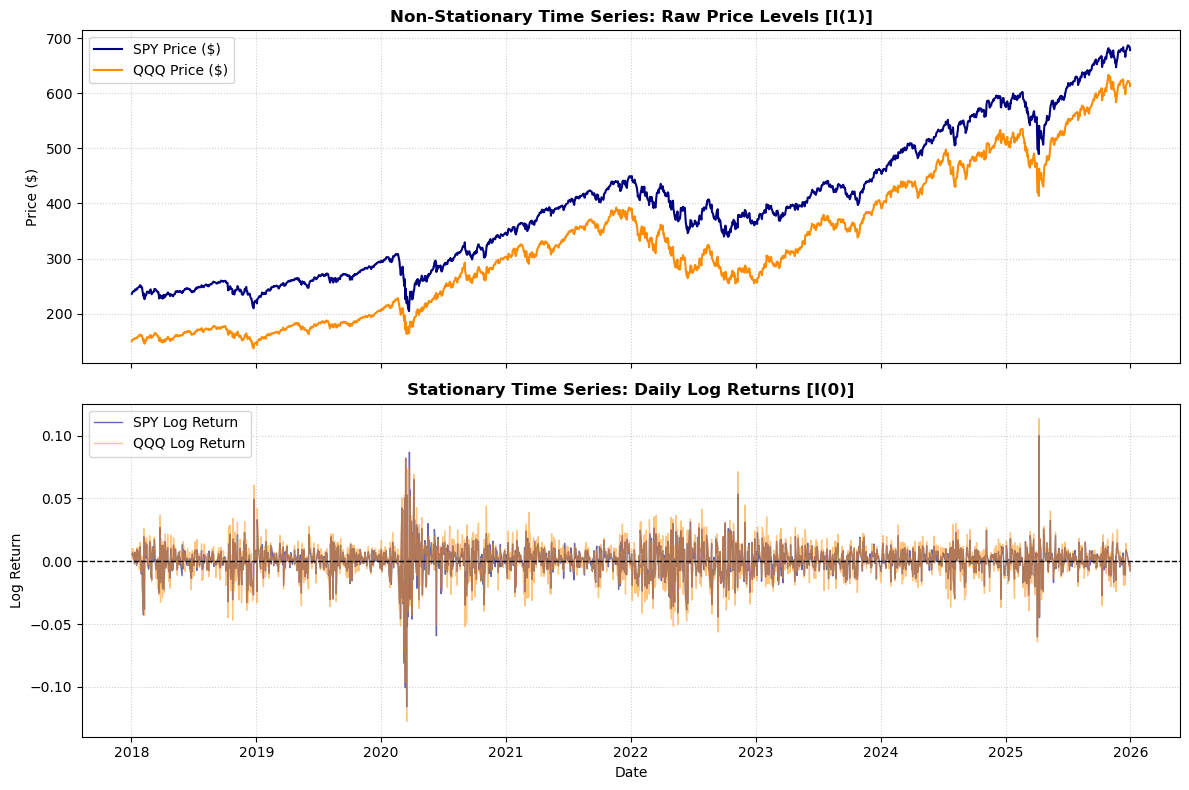

In [180]:
def evaluate_adf_stationarity(series,series_name):
    clean_series=series.dropna()

    # reun ADF test selecting optimal lag using Akaike Information Criterion (AIC)
    result=adfuller(clean_series,autolag="AIC")
    adf_stat=result[0]
    p_value=result[1]
    crit_vals=result[4]

    print("--------------------------------------------------------------------------")
    print(f"\nADF Test Results for {series_name}")
    print(f"ADF Statistic: {adf_stat:.4f}")
    print(f"p-value: {p_value:.4e}")
    print("Critical Values:")
    for level,value in crit_vals.items():
        print(f" {level}: {value:.4f}")
    if p_value<0.05:
        print(f"\n=> Conclusion: Reject H_0 at 5% level (p<0.05).")
        print(f" '{series_name}' is stationary [I(0)].\n")
        print("--------------------------------------------------------------------------")
    else:
        print(f"\n=> Conclusion: Fail to reject H_0 (p>=0.05).")
        print(f" '{series_name}' is non-stationary [I(1)]. Unit root present.\n")
        print("--------------------------------------------------------------------------")

# test raw price levels
# we expect these to be non-stationary I(1)
evaluate_adf_stationarity(prices["SPY"], "SPY Raw Price Level")
evaluate_adf_stationarity(prices["QQQ"], "QQQ Raw Price Level")

# test daily log returns
# we expect these to be stationary I(0)
evaluate_adf_stationarity(log_returns["SPY"], "SPY Daily Log Returns")
evaluate_adf_stationarity(log_returns["QQQ"], "QQQ Daily Log Returns")

fig,axes=plt.subplots(2,1,figsize=(12,8),sharex=True)
# top plot: non-stationary price levels I(1)
axes[0].plot(prices.index, prices["SPY"], label="SPY Price ($)", color="navy", linewidth=1.5)
axes[0].plot(prices.index, prices["QQQ"], label="QQQ Price ($)", color="darkorange", linewidth=1.5)
axes[0].set_title("Non-Stationary Time Series: Raw Price Levels [I(1)]", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Price ($)", fontsize=10)
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle=":", alpha=0.6)

# bottom plot: stationary log returns I(0)
axes[1].plot(log_returns.index, log_returns["SPY"], label="SPY Log Return", color="navy", alpha=0.6, linewidth=1.0)
axes[1].plot(log_returns.index, log_returns["QQQ"], label="QQQ Log Return", color="darkorange", alpha=0.5, linewidth=1.0)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_title("Stationary Time Series: Daily Log Returns [I(0)]", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Log Return", fontsize=10)
axes[1].set_xlabel("Date", fontsize=10)
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

From the **SPY** and **QQQ** price levels, we fail to reject $H_0$. Both price series exhibit a unit root, making direct linear modelling inappropriate due to spurious correlation risks.

From the **SPY** and **QQQ** daily log returns, we reject $H_0$ at all significance levels since the p-value is much less than $0.01$. First-differencing raw prices eliminates the trend component, which gives us mean-reverting stationary series.

From the graph above we have two charts on the same x-axis. In the top chart with price levels, the price drifts upwards over time, violating the constant mean assumption. In the botom chart with daily log returns, we have mean-reversion around zero, showing we have time-invariant statistical properties.

### Cointegration Testing (Engle-Granger Two-Step Method)

While raw prices of **SPY** and **QQQ** are both non-stationary $I(1)$ processes, they may share an underlying long-term equilibrium. If a linear combination of two non-stationary series yields a stationary $I(0)$ residual series, the two assets are said to be cointegrated.

- **Correlation**: measures short-term directional co-movement of returns. Two assets can be highly correlated day-to-day but drift arbitrarily far apart over long horizons.
- **Cointegration**: measures long-term equilibrium binding price levels. If a cointegrated pair pulls apart, it's expected to mean-revert back.

#### The Engle-Granger Two-Step Methodology
We estimate the long-term hedge ratio, $\beta$, by running an Ordinary Least Squares (OLS) linear regression of Asset $Y$ (**SPY**) on Asset $X$ (**QQQ**):
$$Y_t=\alpha +\beta X_t +\varepsilon_t,$$
where:
- $Y_t$ = price level of **SPY** at time $t$
- $X_T$ = price level of **QQQ** at time $t$
- $\beta$ = optimal long-term hedge ratio (the cointegrating vector parameter)
- $\alpha$ = intercept term
- $\varepsilon_t$ = residual spread ($\varepsilon_t=Y_t - \alpha -\beta X_t$).

We then get the estimated residual sequence $\hat{\varepsilon}_t$ and test it for stationarity using the ADF test:
$$\Delta\hat{\varepsilon}_t=\gamma\hat{\varepsilon}_{t-1}+\sum_{i=1}^p\delta_i\Delta\hat{\varepsilon}_{t-i}+u_t$$

- Null Hypothesis ($H_0$): $\gamma = 0$. The residual spread $\hat{\varepsilon}_t$ contains a unit root (the assets **ARE NOT** cointegrated)
- Alternative Hypothesis ($H_1$): $\gamma < 0$. The residual spread $\hat{\varepsilon}_t$ is stationary $I(0)$ (the assets **ARE** cointegrated)

The standard Dickey-Fuller critical values cannot be used directly. The residuals $\hat{\varepsilon}_t$ are estimates from an OLS regression. We have to use specialised Engle-Granger/MacKinnon critical values to determine statistical significance.

[*********************100%***********************]  2 of 2 completed


Pair analysis: SPY (Y) vs. QQQ (X)
OLS hedge ratio (beta): 0.9610
OLS intercept (alpha): 83.1035
R-squared: 0.9875
Engle-Granger t-stat: -2.6336
Engle-Granger p-value: 2.2437e-01
Status: NOT COINTEGRATED (I(1) Spread)


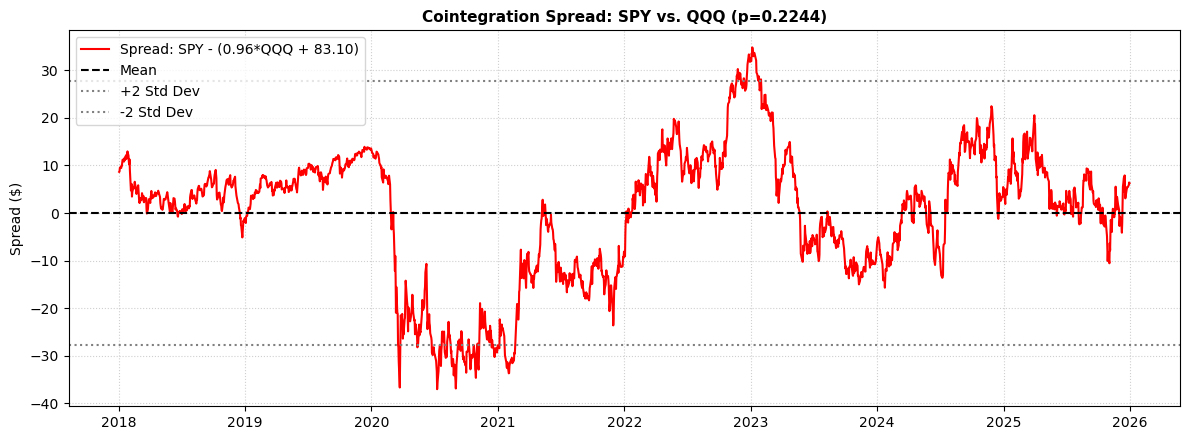

In [183]:
def analyse_pair_cointegration(ticker_y,ticker_x,start_date="2018-01-01",end_date="2026-01-01"):
    tickers=[ticker_y, ticker_x]
    raw_data=yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
    
    # handling single vs multi-index column extraction cleanly
    if isinstance(raw_data.columns,pd.MultiIndex):
        prices=raw_data["Close"][[ticker_y,ticker_x]].copy()
    else:
        prices=raw_data[["Close"]].copy()
    prices=prices.ffill().dropna()
    
    y=prices[ticker_y]
    x=prices[ticker_x]
    
    # running automated Engle-Granger Cointegration Test
    score,p_value,crit_vals=coint(y,x) # computes the OLS regression and uses MacKinnon critical values
    
    # finding explicit hedge ratio (beta) and intercept (alpha)
    X_const=sm.add_constant(x)
    ols_model=sm.OLS(y,X_const).fit()
    alpha=ols_model.params["const"]
    beta=ols_model.params[ticker_x]
    r2=ols_model.rsquared
    
    # constructing the residual spread
    spread=y-(alpha+beta*x)
    
    is_cointegrated=p_value<0.05
    print(f"Pair analysis: {ticker_y} (Y) vs. {ticker_x} (X)")
    print(f"OLS hedge ratio (beta): {beta:.4f}")
    print(f"OLS intercept (alpha): {alpha:.4f}")
    print(f"R-squared: {r2:.4f}")
    print(f"Engle-Granger t-stat: {score:.4f}")
    print(f"Engle-Granger p-value: {p_value:.4e}")
    print(f"Status: {'COINTEGRATED (I(0) Spread)' if is_cointegrated else 'NOT COINTEGRATED (I(1) Spread)'}")
    
    plt.figure(figsize=(12,4.5))
    plt.plot(spread.index,spread,label=f"Spread: {ticker_y} - ({beta:.2f}*{ticker_x} + {alpha:.2f})",color="green" if is_cointegrated else "red")
    plt.axhline(spread.mean(),color="black",linestyle="--",label="Mean")
    plt.axhline(spread.mean()+2*spread.std(),color="gray",linestyle=":",label="+2 Std Dev")
    plt.axhline(spread.mean()-2*spread.std(),color="gray",linestyle=":",label="-2 Std Dev")
    plt.title(f"Cointegration Spread: {ticker_y} vs. {ticker_x} (p={p_value:.4f})",fontsize=11,fontweight="bold")
    plt.ylabel("Spread ($)")
    plt.legend(loc="upper left")
    plt.grid(True,linestyle=":",alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    # returning structured results dictionary for downstream backtesting
    return {
        "ticker_y": ticker_y,
        "ticker_x": ticker_x,
        "prices": prices,
        "beta": beta,
        "alpha": alpha,
        "spread": spread,
        "p_value": p_value,
        "is_cointegrated": is_cointegrated
    }

spy_qqq_results=analyse_pair_cointegration("SPY","QQQ")

We can see that although **SPY** and **QQQ** have an extremely high linear fit ($R^2 = 98.75\%$), **SPY** and **QQQ** raw prices fail the Engle-Granger test. This means that a static linear combination yields a non-stationary ($I(1)$) residual spread. The residual graph shows extended multi-year regimes where the spread remains far from zero. Implementing a static pairs trading strategy on **SPY**/**QQQ** over long horizons exposes a portfolio to unbounded drift risk.

Let us try to find a pair of stocks that are cointegrated.

[*********************100%***********************]  2 of 2 completed


Pair analysis: GOOGL (Y) vs. GOOG (X)
OLS hedge ratio (beta): 0.9910
OLS intercept (alpha): 0.4370
R-squared: 0.9998
Engle-Granger t-stat: -3.6627
Engle-Granger p-value: 2.0448e-02
Status: COINTEGRATED (I(0) Spread)


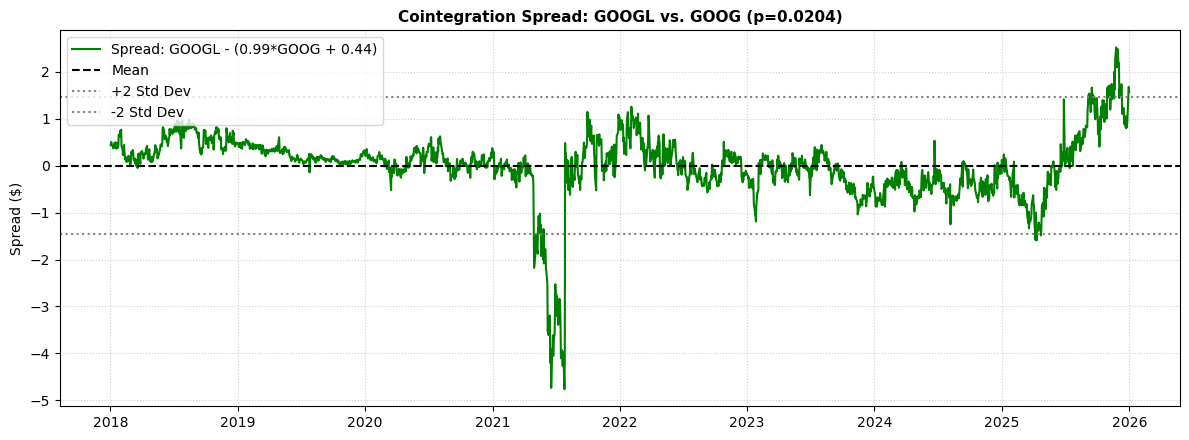

[*********************100%***********************]  2 of 2 completed


Pair analysis: EWA (Y) vs. EWC (X)
OLS hedge ratio (beta): 0.4275
OLS intercept (alpha): 6.1399
R-squared: 0.9287
Engle-Granger t-stat: -2.1716
Engle-Granger p-value: 4.3904e-01
Status: NOT COINTEGRATED (I(1) Spread)


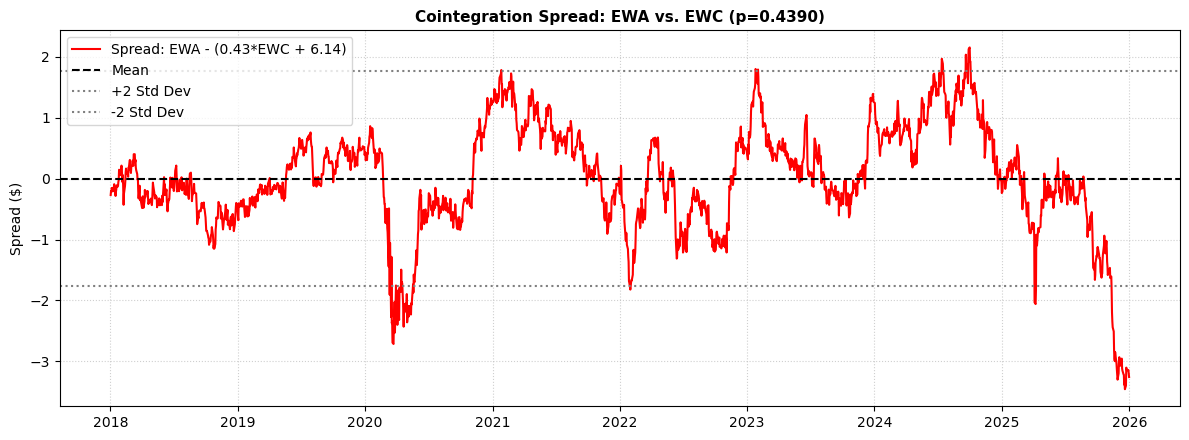

[*********************100%***********************]  2 of 2 completed


Pair analysis: KO (Y) vs. PEP (X)
OLS hedge ratio (beta): 0.3270
OLS intercept (alpha): 7.9051
R-squared: 0.6520
Engle-Granger t-stat: -0.6396
Engle-Granger p-value: 9.5278e-01
Status: NOT COINTEGRATED (I(1) Spread)


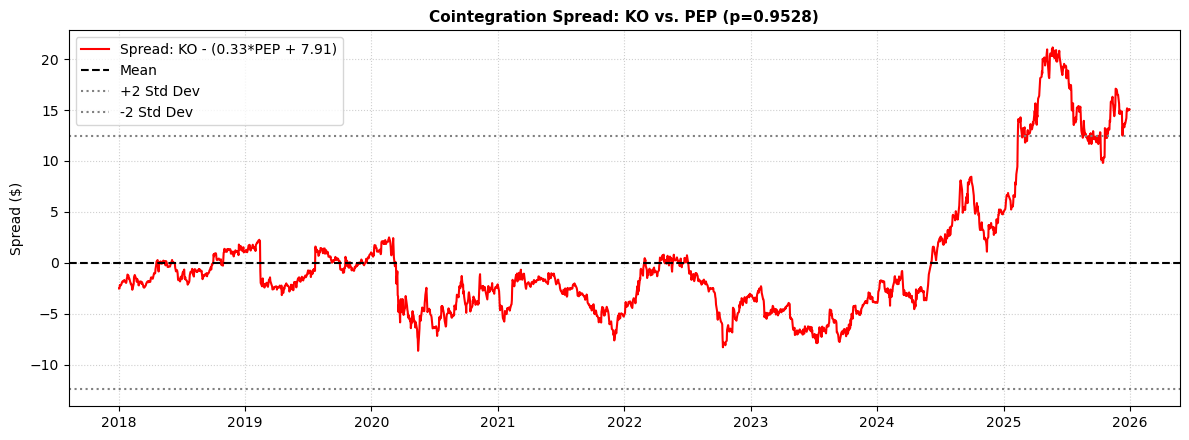

In [185]:
goog_results = analyse_pair_cointegration("GOOGL", "GOOG") # Alphabet Class A vs. Class C
ewa_ewc_results = analyse_pair_cointegration("EWA", "EWC") # Australia vs. Canada ETFs
ko_pep_results = analyse_pair_cointegration("KO", "PEP") # Coca-Cola vs. PepsiCo

We can see that we have found a pair: **GOOGL** and **GOOG**, which are Alphabet Class A and Alphabet Class C respectively. These both represent the same underlying asset, which makes it reasonable for these two to be cointegrated. So we can safely exploit the stationary $I(0)$ residual spread for statistical arbitrage without exposure to long term drift risk.

Using the estimated linear relationship from our Engle-Granger regression, the daily residual spread $\varepsilon_t$ represents the pricing difference between the two share classes:
$$\varepsilon_t=Y_t-(\alpha +\beta X_t)$$
where $Y_t$ is the price of **GOOGL**, $X_T$ is the price of **GOOG**, $\beta$ is the hedge ratio, and $\alpha$ is the structural intercept.

Because market regimes and short-term volatility can shift over time, using a fixed static deviation threshold can lead to miscalibrated signals. We instead have to standardise the spread using a rolling $N$ day sample mean ($\mu_N$) and standard deviation ($\sigma_N$)
$$Z_t=\frac{\varepsilon_t -\mu_{t,N}}{\sigma_{t,N}}$$
where
$$\mu_{t,N}=\frac{1}{N}\sum_{i=0}^{N-1}\varepsilon_{t-i}$$
$$\sigma_{t,N}=\sqrt{\frac{1}{N-1}\sum_{i=0}^{N-1}\varepsilon_{t-i}}$$

We establish some entry thresholds ($\pm Z_{\text{entry}}$) and a mean-reversion exit threshold ($Z_{\text{exit}}=0$):

- Long spread entry ($Z_t\leq -Z_{\text{entry}}$): **GOOGL** is significantly undervalued relative to **GOOGG**. Buy $1$ unit of **GOOGL**, short $\beta$ units of **GOOG**

- Short spread entry ($Z_t\geq +Z_{\text{entry}}$): **GOOGL** is significantly overvalued relative to **GOOG**. Short $1$ unit of **GOOGL**, buy $\beta$ units of **GOOG**

- Spread exit ($|Z_t|\leq Z_{\text{exit}}$): the price divergence has collapsed back to historical equilibrium ($\mu_N$). Flatten all positions.

                  GOOGL Benchmark (Buy & Hold) Pairs Strategy (Gross)  \
CAGR                                    23.54%                  1.50%   
Annual Volatility                       31.10%                  1.01%   
Sharpe Ratio                              0.84                   1.48   
Max Drawdown                           -44.32%                 -0.78%   

                  Pairs Strategy (Net)  
CAGR                             0.50%  
Annual Volatility                1.02%  
Sharpe Ratio                      0.50  
Max Drawdown                    -0.98%  


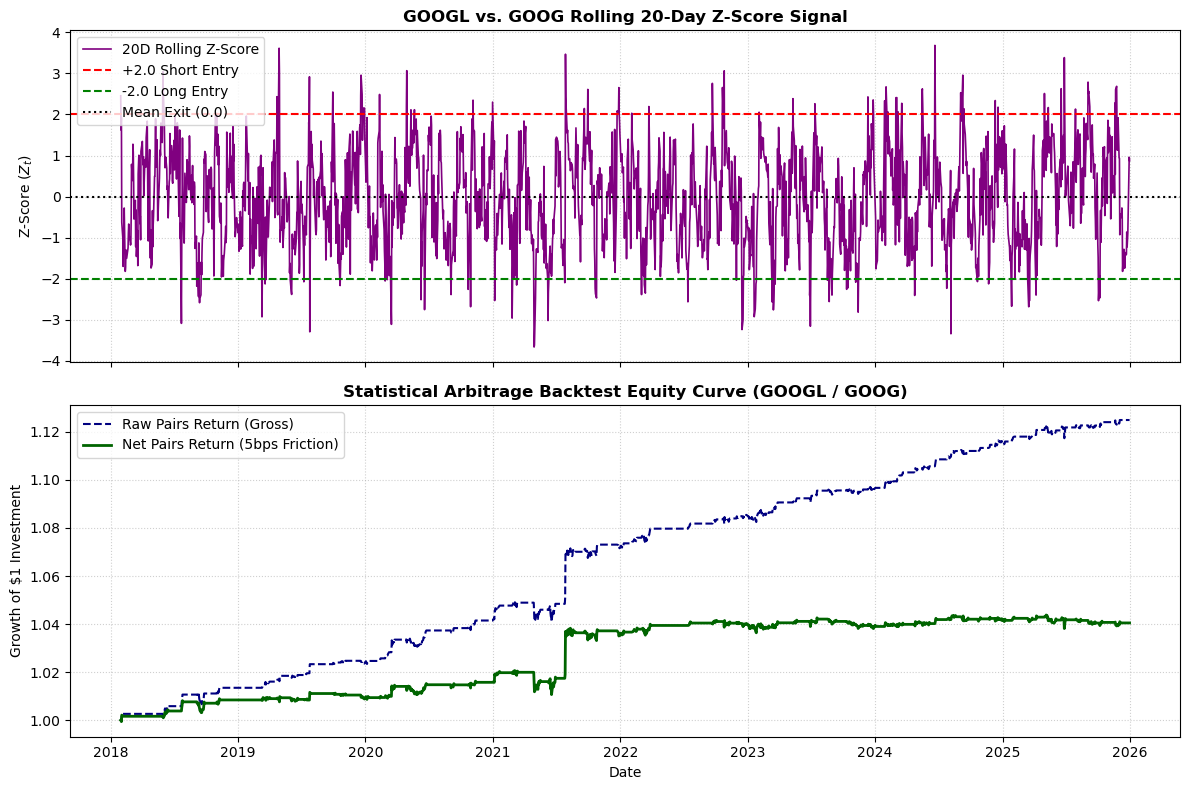

In [188]:
entry_z=2.0
exit_z=0.0
cost_bps=0.0005
# extrqcting data from the analyse_pair_cointegration dictionary
ticker_y=goog_results["ticker_y"]
ticker_x=goog_results["ticker_x"]
prices=goog_results["prices"].copy()
beta=goog_results["beta"]
alpha=goog_results["alpha"]
spread=goog_results["spread"].copy()

# Construct working DataFrame
df=pd.DataFrame({"Spread": spread})
df[ticker_y]=prices[ticker_y]
df[ticker_x]=prices[ticker_x]

# 1. Compute rolling Z-Score over specified lookback window
df["Spread_Mean"]=df["Spread"].rolling(window=lookback).mean()
df["Spread_Std"]=df["Spread"].rolling(window=lookback).std()
df["Z_Score"]=(df["Spread"]-df["Spread_Mean"])/df["Spread_Std"]

position = 0
raw_signals = []

for z in df["Z_Score"]:
    if pd.isna(z):
        raw_signals.append(0)
        continue
    if position==0:
        if z<=-entry_z:
            position=1   # long spread
        elif z >= entry_z:
            position = -1  # short spread
    elif position==1:
        if z>=-exit_z:
            position=0   # exit long spread at mean
    elif position==-1:
        if z<=exit_z:
            position=0   # exit short spread at mean
            
    raw_signals.append(position)
    
df["Raw_Signal"]=raw_signals
df["Position"]=df["Raw_Signal"].shift(1)

# calculating asset simple returns
df["Ret_Y"] = df[ticker_y].pct_change()
df["Ret_X"] = df[ticker_x].pct_change()

# capital-weighted spread return
capital_scale = 1.0 + abs(beta)
df["Spread_Return_Gross"]=df["Position"]*(df["Ret_Y"]-beta*df["Ret_X"])/capital_scale

# considering transaction costs
df["Turnover"]=df["Position"].diff().abs()
df.loc[df["Position"].notna() & df["Position"].shift(1).isna(),"Turnover"]=df["Position"].abs()
df["Transaction_Cost"]=df["Turnover"]*cost_bps
df["Spread_Return_Net"]=df["Spread_Return_Gross"]-df["Transaction_Cost"]

df_clean = df.dropna(subset=["Z_Score", "Spread_Return_Net"]).copy()

# cumulative growth
df_clean["Cumulative_Gross"]=(1+df_clean["Spread_Return_Gross"]).cumprod()
df_clean["Cumulative_Net"]=(1+df_clean["Spread_Return_Net"]).cumprod()

# computing performance metrics table
benchmark_returns = df_clean["Ret_Y"]  # using GOOGL buy-and-hold as baseline comparison

metrics_summary = pd.DataFrame({
    "GOOGL Benchmark (Buy & Hold)":calculate_performance_metrics(benchmark_returns),
    "Pairs Strategy (Gross)":calculate_performance_metrics(df_clean["Spread_Return_Gross"]),
    "Pairs Strategy (Net)":calculate_performance_metrics(df_clean["Spread_Return_Net"])
})
print(metrics_summary)

# plotting z-score triggers and cumulative returns
fig,axes=plt.subplots(2,1,figsize=(12,8),sharex=True)

# top plot: rolling z-score and signal triggers
axes[0].plot(df_clean.index,df_clean["Z_Score"],label=f"{lookback}D Rolling Z-Score",color="purple",linewidth=1.2)
axes[0].axhline(entry_z,color="red",linestyle="--",label=f"+{entry_z} Short Entry")
axes[0].axhline(-entry_z,color="green",linestyle="--",label=f"-{entry_z} Long Entry")
axes[0].axhline(exit_z,color="black",linestyle=":",label="Mean Exit (0.0)")
axes[0].set_title(f"GOOGL vs. GOOG Rolling {lookback}-Day Z-Score Signal",fontsize=12,fontweight="bold")
axes[0].set_ylabel("Z-Score ($Z_t$)",fontsize=10)
axes[0].legend(loc="upper left")
axes[0].grid(True,linestyle=":",alpha=0.6)

# bottom plot: equity curve
axes[1].plot(df_clean.index,df_clean["Cumulative_Gross"],label="Raw Pairs Return (Gross)",color="navy",linestyle="--",linewidth=1.5)
axes[1].plot(df_clean.index,df_clean["Cumulative_Net"],label="Net Pairs Return (5bps Friction)",color="darkgreen",linewidth=2.0)
axes[1].set_title("Statistical Arbitrage Backtest Equity Curve (GOOGL / GOOG)",fontsize=12,fontweight="bold")
axes[1].set_xlabel("Date",fontsize=10)
axes[1].set_ylabel("Growth of $1 Investment",fontsize=10)
axes[1].legend(loc="upper left")
axes[1].grid(True,linestyle=":",alpha=0.6)

plt.tight_layout()
plt.show()

Market risk is almost entirely hedged out here. Our MDD and annual volatility are both far below the **GOOGL** benchmark's. The gross Sharpe ratio beats the benchmark, but transaction costs eat a large share of the modest CAGR. The above graph massively illustrates the losses we face from transaction costs.

While the CAGR is relatively low, our extremely low annual volatility and MDD mean that we could perform leverage scaling, which could scale our returns to target higher risk levels while minimising market risk exposure.